# Figure 2 — Melody outperforms existing methods in methylation prediction

This notebook reproduces panels **A–B, C, D, E, F, G, H, I** of Figure 2 directly from the
exported CSV source files in `./Data/Figure2`.

Models compared: **Melody-MT**, **Melody-ST** (this work) vs. **INTERACT**, **CpGenie**,
**iDNA-ABT** (baselines). Unless noted, evaluation pools chr1–22 + chrX (chrY excluded),
across the 39 cell-type datasets.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

CSV_DIR = next((os.path.join(r, 'Data', 'Figure2') for r in (os.getcwd(), os.path.dirname(os.getcwd())) if os.path.isdir(os.path.join(r, 'Data', 'Figure2'))), './Data/Figure2')
MODEL_ORDER = ['Melody-MT', 'Melody-ST', 'INTERACT', 'CpGenie', 'iDNA-ABT']
COLORS = {'Melody-MT': '#3F51B5', 'Melody-ST': '#7986CB',
          'INTERACT': '#C4B17D', 'CpGenie': '#81C784', 'iDNA-ABT': '#E57373'}
rng = np.random.default_rng(0)
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

## Figure 2A–B — Performance across data splits
Per-track AUC (A) and Spearman correlation (B) for each model across five evaluation splits
(validation / test chromosomes, hypomethylated sampling valid / test, and cell-type-specific
regions). Each dot is one of the 39 cell-type datasets; the bar marks the mean.

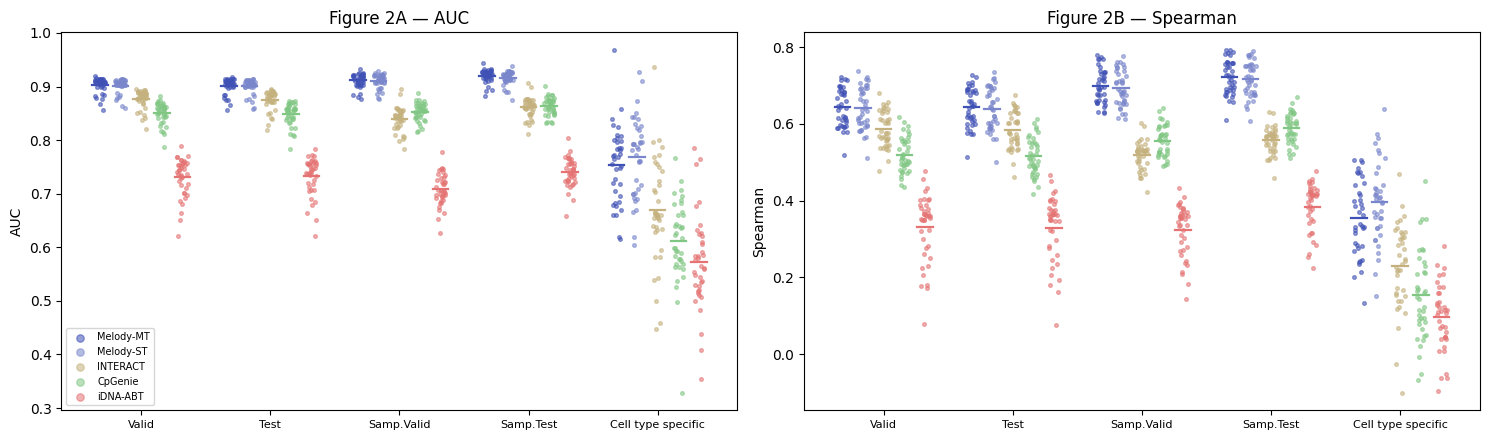

In [2]:
df = pd.read_csv(f'{CSV_DIR}/figure_2AB.csv')
splits = ['VALID', 'TEST', 'SAMPLE_VALID', 'SAMPLE_TEST', 'cell type specific']
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, (panel, metric) in zip(axes, [('A', 'AUC'), ('B', 'Spearman')]):
    sub = df[df['metric'] == metric]
    for mi, model in enumerate(MODEL_ORDER):
        off = (mi - 2) * 0.16
        for si, sp in enumerate(splits):
            v = sub[(sub['model'] == model) & (sub['split'] == sp)]['value'].to_numpy()
            if len(v) == 0:
                continue
            x = si + off + rng.uniform(-0.04, 0.04, len(v))
            ax.scatter(x, v, s=7, color=COLORS[model], alpha=0.55,
                       label=model if si == 0 else None)
            ax.plot([si + off - 0.06, si + off + 0.06], [v.mean()] * 2, color=COLORS[model], lw=1.6)
    ax.set_xticks(range(len(splits)))
    ax.set_xticklabels(['Valid', 'Test', 'Samp.Valid', 'Samp.Test', 'Cell type specific'], fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(f'Figure 2{panel} — {metric}')
axes[0].legend(fontsize=7, markerscale=2, loc='lower left')
plt.tight_layout(); plt.show()

## Figure 2C — Per-chromosome Pearson correlation and MSE
Mean (over 39 cell types) Pearson correlation and MSE on each chromosome.

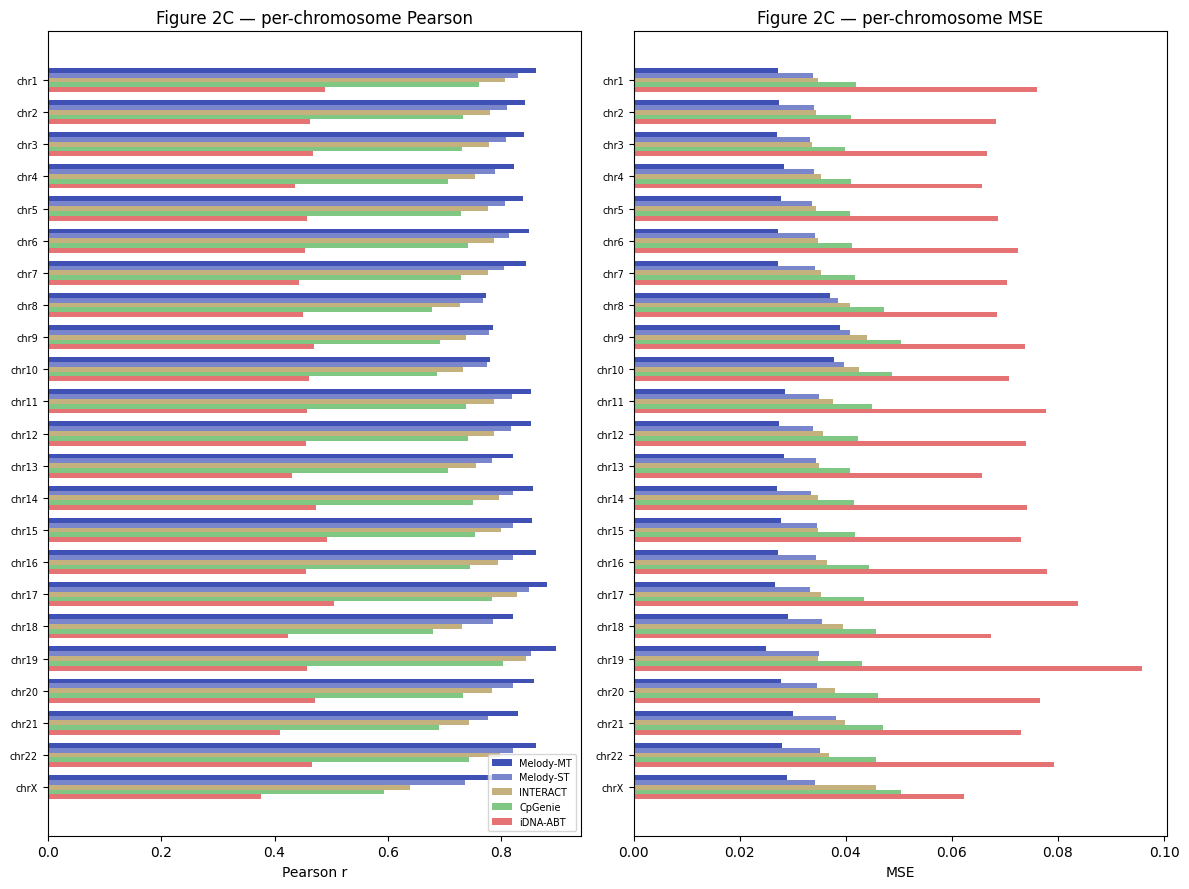

In [3]:
df = pd.read_csv(f'{CSV_DIR}/figure_2C.csv')
agg = df.groupby(['chr', 'model'])[['corr', 'mse']].mean().reset_index()
chr_order = ['chr%d' % i for i in range(1, 23)] + ['chrX']
chr_order = [c for c in chr_order if c in set(agg['chr'])]
y = np.arange(len(chr_order)); h = 0.15
fig, axes = plt.subplots(1, 2, figsize=(12, 9))
for mi, model in enumerate(MODEL_ORDER):
    s = agg[agg['model'] == model].set_index('chr')
    corr = [s.loc[c, 'corr'] if c in s.index else np.nan for c in chr_order]
    mse = [s.loc[c, 'mse'] if c in s.index else np.nan for c in chr_order]
    axes[0].barh(y + (mi - 2) * h, corr, height=h, color=COLORS[model], label=model)
    axes[1].barh(y + (mi - 2) * h, mse, height=h, color=COLORS[model])
for ax, lbl in zip(axes, ['Pearson r', 'MSE']):
    ax.set_yticks(y); ax.set_yticklabels(chr_order, fontsize=7); ax.set_xlabel(lbl)
    ax.invert_yaxis()
axes[0].set_title('Figure 2C — per-chromosome Pearson'); axes[0].legend(fontsize=7)
axes[1].set_title('Figure 2C — per-chromosome MSE')
plt.tight_layout(); plt.show()

## Figure 2D — ROC curves
ROC curves pooled across all cell types and chromosomes (chrY excluded). AUROC in the legend.

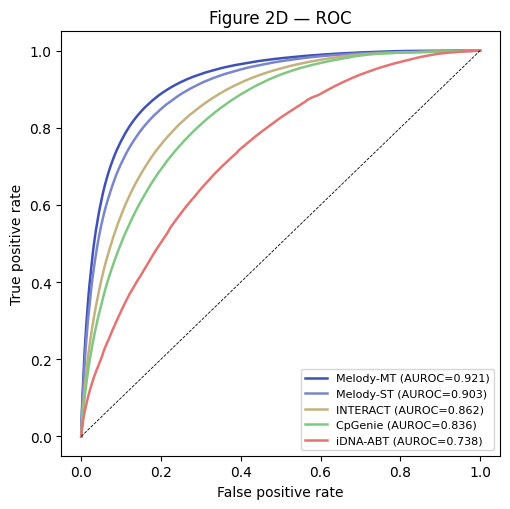

In [4]:
df = pd.read_csv(f'{CSV_DIR}/figure_2D.csv')
plt.figure(figsize=(5.2, 5.2))
for model in MODEL_ORDER:
    s = df[df['model'] == model].sort_values('fpr')
    auc = trapz(s['tpr'], s['fpr'])
    plt.plot(s['fpr'], s['tpr'], color=COLORS[model], lw=1.8, label=f'{model} (AUROC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=0.6)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('Figure 2D — ROC'); plt.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

## Figure 2E — Precision–Recall curves
AUPRC in the legend.

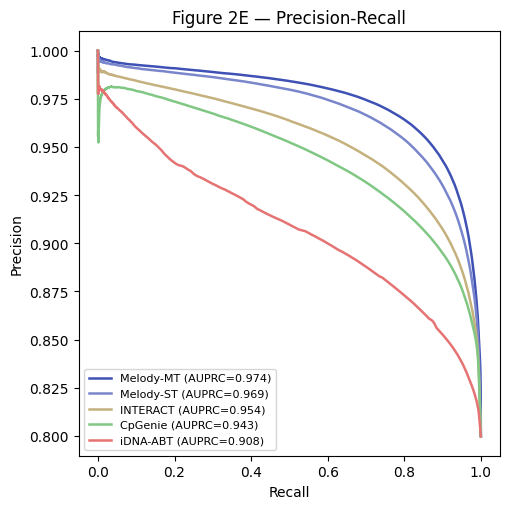

In [5]:
df = pd.read_csv(f'{CSV_DIR}/figure_2E.csv')
plt.figure(figsize=(5.2, 5.2))
for model in MODEL_ORDER:
    s = df[df['model'] == model].sort_values('recall')
    ap = trapz(s['precision'][::-1], s['recall'][::-1])
    plt.plot(s['recall'], s['precision'], color=COLORS[model], lw=1.8, label=f'{model} (AUPRC={abs(ap):.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Figure 2E — Precision-Recall'); plt.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

## Figure 2F — MSE by methylation state
MSE stratified by ground-truth methylation level (truth-bin midpoint).

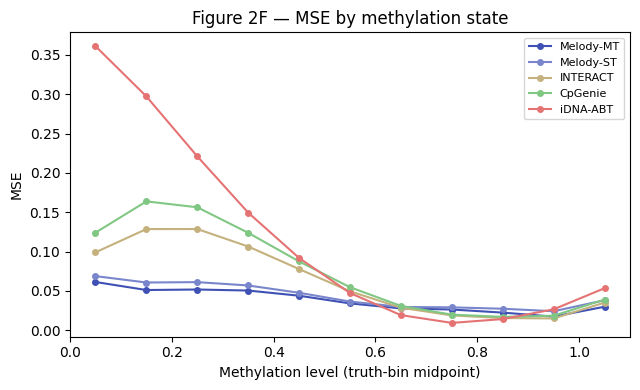

In [6]:
df = pd.read_csv(f'{CSV_DIR}/figure_2F.csv')
plt.figure(figsize=(6.5, 4))
for model in MODEL_ORDER:
    s = df[df['model'] == model].sort_values('bin_mid')
    plt.plot(s['bin_mid'], s['mse'], marker='o', ms=4, color=COLORS[model], label=model)
plt.xlabel('Methylation level (truth-bin midpoint)'); plt.ylabel('MSE')
plt.title('Figure 2F — MSE by methylation state'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Figure 2G — AUC for seven representative cell types
Per-cell AUC on the validation and test chromosomes for seven representative cell types.

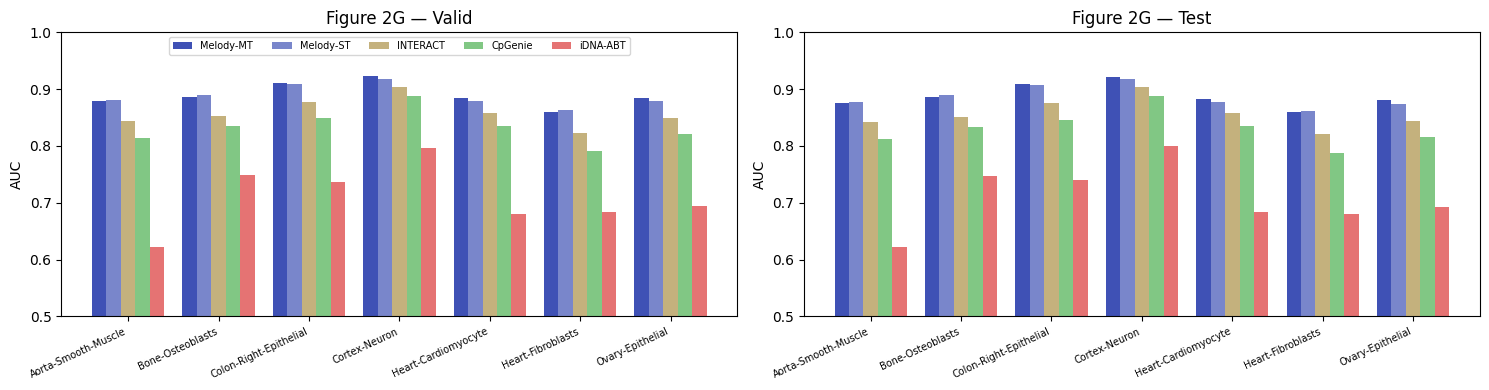

In [7]:
df = pd.read_csv(f'{CSV_DIR}/figure_2G.csv')
cells = sorted(df['track'].unique())
x = np.arange(len(cells)); w = 0.16
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, split in zip(axes, ['VALID', 'TEST']):
    sub = df[df['split'] == split]
    for mi, model in enumerate(MODEL_ORDER):
        vals = [sub[(sub['track'] == c) & (sub['model'] == model)]['AUC'].mean() for c in cells]
        ax.bar(x + (mi - 2) * w, vals, width=w, color=COLORS[model], label=model if split == 'VALID' else None)
    ax.set_xticks(x); ax.set_xticklabels(cells, rotation=25, ha='right', fontsize=7)
    ax.set_ylim(0.5, 1.0); ax.set_ylabel('AUC'); ax.set_title(f'Figure 2G — {split.title()}')
axes[0].legend(fontsize=7, ncol=5, loc='upper center')
plt.tight_layout(); plt.show()

## Figure 2H — MAE vs. input sequence length
Per-track MAE on the validation set for Melody-MT trained at 1/2/10/20/50-kb input windows.

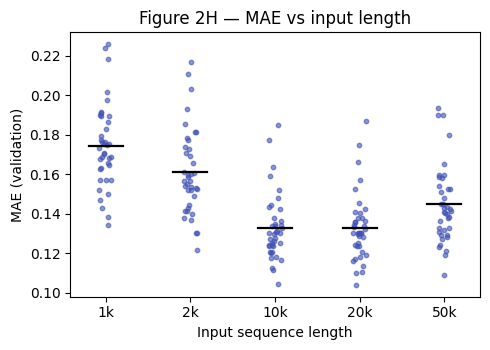

In [8]:
df = pd.read_csv(f'{CSV_DIR}/figure_2H.csv')
lengths = sorted(df['input_length_bp'].unique())
plt.figure(figsize=(5, 3.6))
for i, L in enumerate(lengths):
    v = df[df['input_length_bp'] == L]['MAE_valid'].to_numpy()
    x = i + rng.uniform(-0.08, 0.08, len(v))
    plt.scatter(x, v, s=10, alpha=0.6, color='#3F51B5')
    plt.plot([i - 0.2, i + 0.2], [v.mean()] * 2, 'k', lw=1.6)
plt.xticks(range(len(lengths)), ['%dk' % (L // 1000) for L in lengths])
plt.xlabel('Input sequence length'); plt.ylabel('MAE (validation)')
plt.title('Figure 2H — MAE vs input length'); plt.tight_layout(); plt.show()

## Figure 2I — Cell-type-specific MAE across (alpha, beta) loss weights

Mean absolute error in cell-type-specific regions for five loss-weight configurations.


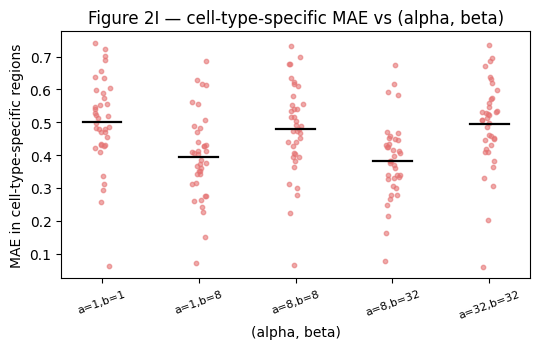

In [9]:
df = pd.read_csv(f'{CSV_DIR}/figure_2I.csv')
order = ['a=1,b=1', 'a=1,b=8', 'a=8,b=8', 'a=8,b=32', 'a=32,b=32']
plt.figure(figsize=(5.5, 3.6))
for i, cfg in enumerate(order):
    v = df[df['alpha_beta'] == cfg]['MAE'].to_numpy()
    x = i + rng.uniform(-0.08, 0.08, len(v))
    plt.scatter(x, v, s=10, alpha=0.6, color='#E57373')
    plt.plot([i - 0.2, i + 0.2], [v.mean()] * 2, 'k', lw=1.6)
plt.xticks(range(len(order)), order, rotation=20, fontsize=8)
plt.xlabel('(alpha, beta)'); plt.ylabel('MAE in cell-type-specific regions')
plt.title('Figure 2I — cell-type-specific MAE vs (alpha, beta)'); plt.tight_layout(); plt.show()

## Figure 2J — Auxiliary-loss weighting (CpG-count vs regional-average)
Mean absolute error (MAE) at CpG sites on the validation set, averaged across n=39 cell types,
for combinations of the regional-average loss weight (rows) and the CpG-count loss weight
(columns). Lower is better; the (regional-average = 1, CpG-count = 0.01) configuration — the
one used by Melody-MT — achieves the lowest MAE.

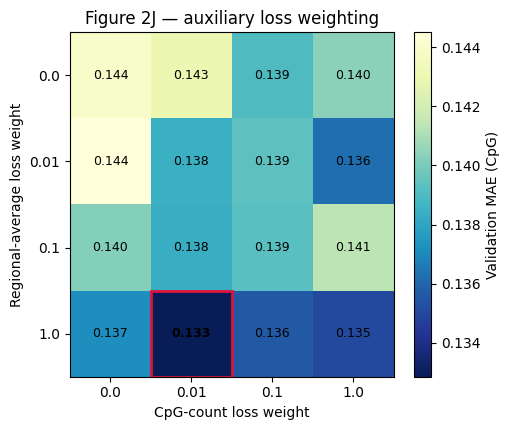

In [10]:
df = pd.read_csv(f'{CSV_DIR}/figure_2J.csv')
piv = df.pivot_table(index='avg_num', columns='cg_num', values='mean').sort_index().sort_index(axis=1)
M = piv.to_numpy()
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(M, cmap='YlGnBu_r', aspect='auto')  # MAE: lower is better -> darker
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
ax.set_xlabel('CpG-count loss weight'); ax.set_ylabel('Regional-average loss weight')
best = np.unravel_index(np.nanargmin(M), M.shape)
for (r, c), v in np.ndenumerate(M):
    ax.text(c, r, f'{v:.3f}', ha='center', va='center', fontsize=9,
            fontweight='bold' if (r, c) == best else 'normal')
ax.add_patch(plt.Rectangle((best[1] - 0.5, best[0] - 0.5), 1, 1, fill=False, edgecolor='crimson', lw=2))
plt.colorbar(im, ax=ax, label='Validation MAE (CpG)')
ax.set_title('Figure 2J — auxiliary loss weighting'); plt.tight_layout(); plt.show()